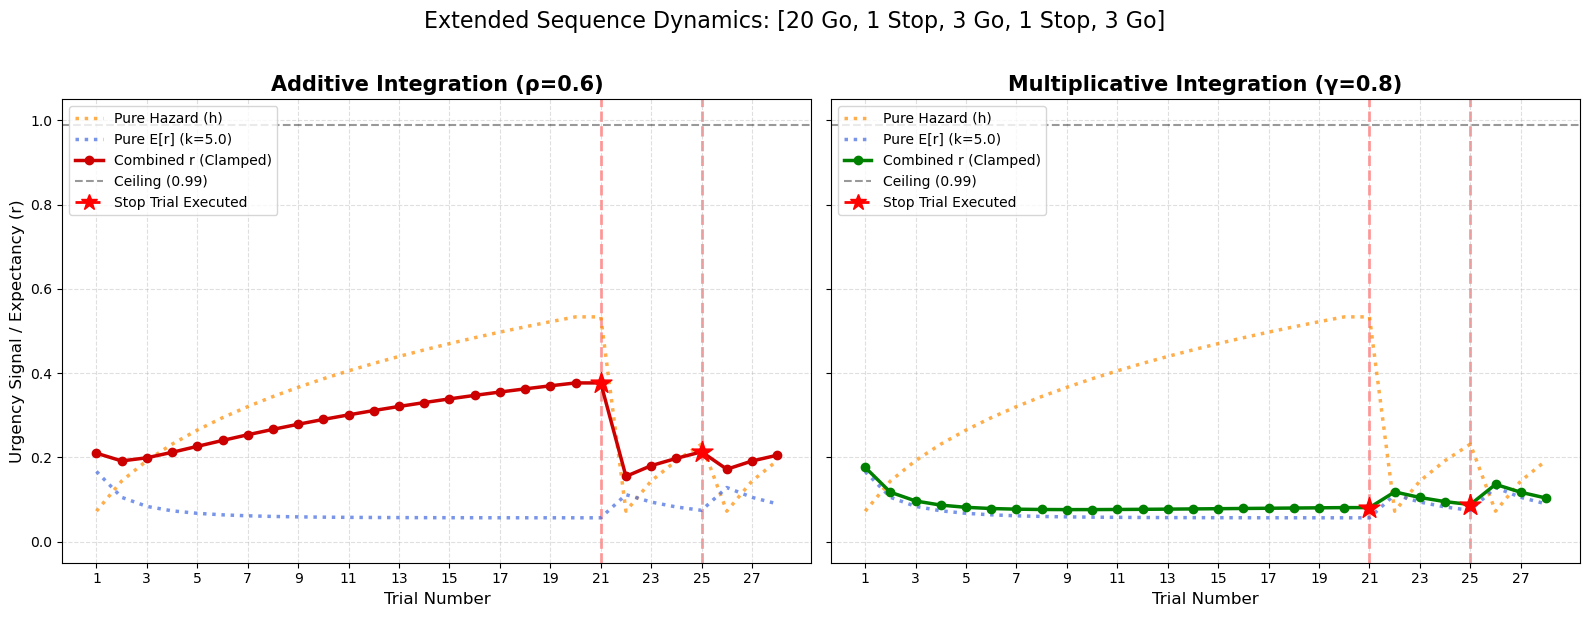

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================
# 1. 核心自由参数区 (Free Parameters)
# 随时在这里调参，不需要修改下方的代码！
# ==========================================
ALPHA_GO = 0.7      # Go 试次的记忆保留率
ALPHA_STOP = 0.80    # Stop 试次的认知重置率 (遗忘率)
K_GO = 5.0           # 每次 Go 带来的习惯冲动增量
RHO = 0.6            # 加法模型中 Hazard 的权重
GAMMA = 0.8          # 乘法模型中 Hazard 的放大系数

# ==========================================
# 2. 实验数据与核心模拟函数
# ==========================================
# 标准的 Weibull Hazard (20个 Trial)
HAZARD_VALS = np.array([
    0.0723, 0.1439, 0.1924, 0.2315, 0.2649,
    0.2943, 0.3206, 0.3445, 0.3664, 0.3867,
    0.4055, 0.4232, 0.4397, 0.4553, 0.4701,
    0.4841, 0.4974, 0.5100, 0.5221, 0.5336
])

# 核心序列: 20 Go -> 1 Stop -> 3 Go -> 1 Stop -> 3 Go
trials = [0]*20 + [1] + [0]*3 + [1] + [0]*3
n_trials = len(trials)
time_steps = np.arange(1, n_trials + 1)

def simulate_sequence(fusion_type='additive'):
    """运行混合机制模型，计算完整的 E[r], h 和 r 轨迹"""
    a, b = 5.0, 1.0  # 先验
    run_length = 0   # 连击计数器
    Er_traj, h_traj, r_traj = [], [], []
    
    for t in trials:
        # 1. 试次前：计算当前的主观期望
        Er = b / (a + b)
        idx = min(run_length, len(HAZARD_VALS) - 1)
        h = HAZARD_VALS[idx]
        
        # 2. 试次前：融合决策信号
        if fusion_type == 'additive':
            r_raw = Er + RHO * h
        elif fusion_type == 'multiplicative':
            r_raw = Er * (1 + GAMMA * h)
            
        r_final = np.clip(r_raw, 0, 0.99) # POMDP 安全截断
        
        Er_traj.append(Er)
        h_traj.append(h)
        r_traj.append(r_final)
        
        # 3. 试次后：物理刺激出现，更新参数模型
        if t == 0: # Go Trial
            a = (1 - ALPHA_GO) * 5.0 + ALPHA_GO * (a + K_GO)
            b = (1 - ALPHA_GO) * 1.0 + ALPHA_GO * (b + 0)
            run_length += 1
        else:      # Stop Trial
            a = (1 - ALPHA_STOP) * 5.0 + ALPHA_STOP * (a + 0)
            b = (1 - ALPHA_STOP) * 1.0 + ALPHA_STOP * (b + 1)
            run_length = 0 # 连击中断，危险率重置
            
    return np.array(Er_traj), np.array(h_traj), np.array(r_traj)

# 运行模拟
Er_add, h_add, r_add = simulate_sequence('additive')
Er_mult, h_mult, r_mult = simulate_sequence('multiplicative')

# ==========================================
# 3. 可视化模块 (1行2列)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

def plot_panel(ax, Er, h, r, title, color):
    # 画底色
    ax.plot(time_steps, h, color='darkorange', lw=2.5, linestyle=':', alpha=0.7, label='Pure Hazard (h)')
    ax.plot(time_steps, Er, color='royalblue', lw=2.5, linestyle=':', alpha=0.7, label=f'Pure E[r] (k={K_GO})')
    
    # 画主信号
    ax.plot(time_steps, r, color=color, lw=2.5, marker='o', label='Combined r (Clamped)')
    
    # 标出 Stop 重置点
    for i, t_type in enumerate(trials):
        if t_type == 1:
            ax.axvline(i + 1, color='red', linestyle='--', lw=2, alpha=0.4, zorder=0)
            ax.scatter(i + 1, r[i], color='red', s=250, marker='*', zorder=10)
            
    # 排版
    ax.axhline(0.99, color='black', linestyle='--', alpha=0.4, label='Ceiling (0.99)')
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xlabel('Trial Number', fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(np.arange(1, n_trials + 1, 2))
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # 定制包含红星的图例
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([0], [0], color='red', linestyle='--', lw=2, marker='*', markersize=12))
    labels.append('Stop Trial Executed')
    ax.legend(handles, labels, loc='upper left', fontsize=10)

# 绘制左/右图
plot_panel(axes[0], Er_add, h_add, r_add, f'Additive Integration (ρ={RHO})', '#cc0000')
axes[0].set_ylabel('Urgency Signal / Expectancy (r)', fontsize=12)
plot_panel(axes[1], Er_mult, h_mult, r_mult, f'Multiplicative Integration (γ={GAMMA})', '#008000')

plt.suptitle('Extended Sequence Dynamics: [20 Go, 1 Stop, 3 Go, 1 Stop, 3 Go]', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()